# Premium data manipulation

As they give me all history of written premium, I have built the triangles directly from the dataset that they have given and not trusted on any of NMG's data manipulations (that can be seen from the report).
Therefore, there is no link to the 'historic database' that I created with past data.

I noted that there are some differences to what was generated by NMG but as we don't really present the Ultimate WP etc, I thought ok to leave for now

In [1]:
from pathlib import Path
import sys

#for reading in scripts from config
PROJECT_ROOT = Path().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))



In [2]:
#folder where all the valuation files are stored
exhibits = Path().resolve() / 'exhibits'

from config.plot_defaults import configure_matplotlib
from config.export_exhibits import  ExhibitExporter
from config.helper import one_dim_t_to_frame, convert_t_index_to_integer
from config.table_render import format_output, format_table
from config.global_params import *

**Instruction: **
To run this for each quarter:
1. Take the Gross Written Premium file that they provide us (in excel)
2. Hardcopy all the sheets
2. Remove empty rows at the top of each tab
3. Remove any tab that isn't required (i.e., if they have reconciliation tabs or the fx rates). Note we still need historic years tabs for the UEP!
4. Save this as a new table (so that we differentiate between what we have done and their original file)
5. We want to make sure that all the years of data is in and as they calculate their UEP here, we want to make sure that all historic tabs are up to date. Therefore its easiest to just take their file as is rather than appending anything from elsewhere
6. 

In [163]:
val_date = pd.to_datetime('2026-06-30')


import pandas as pd, chainladder as cl, numpy as np

file_path = '/Users/sivaramankumar/Library/CloudStorage/OneDrive-Personal/_Ryskk/Clients/Sun Re/2026/Q2/manipulated_data/Gross Written Premium_2Q2026_RYSKK.xlsx'

# Load the Excel file with a specific sheet name
sheet_name = '2026'  # Replace with the actual sheet name
df = pd.read_excel(file_path, sheet_name=sheet_name, dtype={'Sign date': object, 'Inception': object, 'Completion': object})

In [164]:
# Check if all dataframes in dfs have the same column names
columns_by_sheet = {sheet: set(df.columns) for sheet, df in dfs.items()}
first_sheet = sheet_names[0]
reference_columns = columns_by_sheet[first_sheet]

for sheet, columns in columns_by_sheet.items():
    if columns != reference_columns:
        print(f"Sheet '{sheet}' has different columns.")
        print(f"Difference: {reference_columns.symmetric_difference(columns)}")
    else:
        print(f"Sheet '{sheet}' has the same columns as '{first_sheet}'.")

Sheet '2026' has the same columns as '2026'.
Sheet '2025' has different columns.
Difference: {'SUN MT paid #16 March26', 'SUN UAE #33 July Paid', 'SUN MT paid #8 July', 'SUN MT paid #10 September', 'SUN UAE #38 December Paid', 'Unnamed: 1', 'Contract', 'SUN MT paid #2 Jan', 'SUN MT paid #14 Jan26', 'SUN UAE #34 August Paid', 'SUN MT paid #7 June', 'SUN UAE #36 October Paid', 'SUN UAE #35 September Paid', 'SUN UAE #31 May Paid', 'SUN UAE #30 April Paid', 'SUN MT paid #4 Mar', 'SUN MT paid #19 April 26', 'SUN MT paid #17 April26', 'SUN MT paid #5 Apr', 'SUN MT paid #3 Feb 25', 'SUN UAE #28 Feb Paid', 'SUN UAE #27 Jan Paid', 'SUN MT paid #9 August', 'SUN sro #35 May Paid', 'SUN MT paid #6 May', 'SUN UAE #32 June Paid', 'SUN UAE #29 March Paid', 'SUN MT paid #16 Mar 26', 'SUN MT paid #13 December', 'SUN MT paid #19 June 26', 'SUN MT paid #15 Feb 26', 'SUN MT paid #11 October', 'SUN MT paid #14 Jan 26', 'SUN UAE #37 November Paid', 'SUN MT paid #17 Apr 26', 'SUN MT paid #15 Feb26', 'SUN MT 

In [165]:
# Merge all dataframes in dfs, aligning columns and filling missing columns with NaN
merged_df = pd.concat(
    [frame.assign(payment_year=int(sheet)) for sheet, frame in dfs.items()],
    axis=0,
    ignore_index=True,
    sort=True
)

In [6]:
## checking number of rows in each sheet in excel vs merged_df counting the excel rows
1098+2438+1575+1180

#2026Q2 Ok!

6291

In [166]:
# CReate unique ID for each row (just so that I can track things better)
merged_df['unique_id_ryskk'] = merged_df.index + 1  # Simple

# LoB Mapping

There are two columns, one called line and the other called AM Best classification. In some circumstances the line isn't detailed enough, so we can borrow info from the other column to infer the LoB. 



In [167]:
list_of_lobs = (merged_df['Line' ].unique())
list_of_lobs_am_best = merged_df['AM Best classification'].unique()

In [168]:
list_of_lobs_am_best

array(['Marine, Aviation & Transport', nan,
       'Fidelity & Surety Financial Guarantee',
       'Fidelity & Surety/ Financial Guarantee',
       'Other liability (Claims made)', 'Other liab (Claims Made)',
       "Comm'l Multi Peril", 'Other liability (Occurance)',
       'Commercial Property', 'X/S Property (Reinsurance)',
       'Other: Personal Accident & Health', 'Surety, Guarantees, Bonds',
       'X/S Property (Reinsurance)\n', 'Motor Phys Damage',
       'X/S Property \n (Reinsurance)', 'XS Property (Reinsurance)',
       'Medical Prof Liab (Claims Made)', 'Other Liab (Occurrence)',
       'Occupational Accident'], dtype=object)

In [169]:
# Mapping for AM Best classification to broader categories
am_best_mapping = {
    # Marine & Aviation
    'Marine, Aviation & Transport': 'Marine, Aviation',
    'Aerospace': 'Marine, Aviation',
    'Marine': 'Marine, Aviation',
    'Aviation': 'Marine, Aviation',

    # Financial
    'Fidelity & Surety Financial Guarantee': 'Financial',
    'Fidelity & Surety/ Financial Guarantee': 'Financial',
    'Surety, Guarantees, Bonds': 'Financial',
    'Financial Guarantee': 'Financial',

    # Liability
    'Other liability (Claims made)': 'Liability',
    'Other liab (Claims Made)': 'Liability',
    'Other liability (claims made)': 'Liability',
    'Other Liab (Claims made)': 'Liability',
    'Other Liab (Occurrence)': 'Liability',
    'Other Liab (Occurrence)': 'Liability',
    'Medical Prof Liab (Claims Made)': 'Liability',

    # Property
    "Comm'l Multi Peril": 'Property',
    'Commercial Property': 'Property',
    'X/S Property (Reinsurance)': 'Property',
    'X/S Property (Reinsurance)\n': 'Property',
    'X/S Property \n (Reinsurance)': 'Property',
    'XS Property (Reinsurance)': 'Property',
    'Construction & Engineering': 'Property',
    'Personal Property': 'Property',
    'Property': 'Property',

    # Personal
    'Other: Personal Accident & Health': 'Personal',
    'Medical- Group': 'Personal',
    'Occupational Accident': 'Personal',
    'Health Reinsurance': 'Personal',
    'Personal Motor': 'Personal',

    # Misc
    'Motor Phys Damage': 'Misc',
    '?': 'Misc',

    # Treaty
    # (If you have treaty-specific classes, add here)
}


In [170]:
len(merged_df['Line'].unique())

61

In [171]:
line_mapping = {
    # --- Marine ---
    "Marine: H&M": "Marine",
    "Marine:H&M": "Marine",
    "Marine: Hull & Machinery": "Marine",
    "Marine: P&I": "Marine",
    "Marine:P&I": "Marine",
    "Marine: Protection & Indemnity": "Marine",
    "Marine: Voyage": "Marine",
    "Marine: Yacht": "Marine",
    "Marine:Yacht": "Marine",
    "Marine: Cargo": "Marine",
    "Cargo": "Marine",
    "Marine: Builders": "Marine",
    "Marine: Builder's": "Marine",
    "Marine: Freightforwarder": "Marine",
    "Marine: Rolling Stock": "Marine",
    "Marine: Rolling stock": "Marine",
    "Marine: Rolling Stoke": "Marine",
    "Marine": "Marine",
    'Marine: Demolition Voyage': "Marine",
    

    # --- Aviation ---
    "Aviation: Hull": "Aviation",
    "Aviation:Hull": "Aviation",
    "Aviation: TPL": "Aviation",
    "Aviation:TPL": "Aviation",
    "Aviation": "Aviation",
    "Aerospace": "Aviation",

    # --- Liability ---
    "Liability: Cyber": "Liability",
    "Liability:Cyber": "Liability",
    "Cyber": "Liability",
    "Other liability (Claims made)":"Liability",
    "Liability: D&O": "Liability",
    "Liability:D&O": "Liability",
    "Liability: Professional indemnity": "Liability",
    "Liability: Professional Indemnity": "Liability",
    "Liability:Professional Indemnity": "Liability",
    "Liability: Profeccional Indemnity": "Liability",
    "Liability: Professional Indemnit": "Liability",
    "Liability: Medical Malpractice": "Liability",
    "Liability: General & Miscellaneous": "Liability",
    "Third Party Liability": "Liability",
    "Liability": "Liability",
    "Liability ": "Liability",
    "Liability:P&I": "Liability",  # operationally liability-type cover
    'Liability: Profeccional indemnity': "Liability",
    'Liability: Profeccional Idemnity': "Liability",

    # --- Financial ---
    "Financial: Surety, Guarantees, Bonds": "Financial",
    "Financial: Guarantees & Bonds": "Financial",
    "Financial: Guarantees&Bonds": "Financial",
    "Financial: Financial: Guarantees & Bonds": "Financial",
    "Financial": "Financial",
    "Financia;: BBB": "Financial",
    "Financial: BBB": "Financial",
    "Financial: Trade Credit": "Financial",
    "Financial : Political Risks": "Financial",
    "Financial: Political Risks": "Financial",
    "Political": "Financial",
    "Financial: Payment undertaking": "Financial",
    "Financial lines: Payment Guarantee": "Financial",
    "Financial lines: Guarantee": "Financial",
    "Financial Guarantee: Payment undertaking": "Financial",
    "Financial guarantee": "Financial",
    "Bonds": "Financial",
    "Surety bonds": "Financial",
    'Financial: Sureties': "Financial",
    " Bonds": "Financial",
    "Financial: Banker’s blanket bonds": "Financial",
    "Financial: Sureties, Bonds": "Financial",

    # --- Treaty ---
    "Premium Treaty: Quota Share": "Treaty",
    "Treaty: Quota Share": "Treaty",
    "Treaty: QS": "Treaty",
    "Treaty:QS": "Treaty",
    "Treaty: Quota": "Treaty",
    "Treaty: Excess of Loss": "Treaty",
    "Treaty: XL": "Treaty",
    "Treaty": "Treaty",
    "Fronting": "Treaty",

    # --- Property ---
    "Property: Energy": "Property",
    "Property: energy": "Property",
    "Property: Upstream energy": "Property",
    "P&C: Energy": "Property",
    "Property: Commercial": "Property",
    "P&C: Commercial": "Property",
    "P&C: Commercial ": "Property",
    "Property: Industrial": "Property",
    "Property:Industrial": "Property",
    "Property: Industrial ": "Property",
    "P&C: Industrial": "Property",
    "Property: Engineering": "Property",
    "Property: CAR/EAR": "Property",
    "Property: Personal": "Property",
    "Property": "Property",

    # --- Personal ---
    "Personal: Health": "Personal",
    "Personal": "Personal",
    "Motor": "Personal",
    "Motor: Hull": "Personal",
    "Motor Hull": "Personal",
    "Motor: TPL": "Personal",

    # --- Misc ---
    "P&C": "Misc",
    "Other lines": "Misc",
    "Other": "Misc",
    "Special lines": "Misc",
    "Structured and complex": "Misc",
    "Specialty: Political Violance": "Misc", # this says commercial property in the AM Best classification, but speciality lines for line.. given the size of this, will keep in misc for now, but may need to reclassify later
    "Other lines": "Misc",
    "-": "Misc",
    None: "Misc",
    float("nan"): "Misc"
}


In [172]:
line_mapping

{'Marine: H&M': 'Marine',
 'Marine:H&M': 'Marine',
 'Marine: Hull & Machinery': 'Marine',
 'Marine: P&I': 'Marine',
 'Marine:P&I': 'Marine',
 'Marine: Protection & Indemnity': 'Marine',
 'Marine: Voyage': 'Marine',
 'Marine: Yacht': 'Marine',
 'Marine:Yacht': 'Marine',
 'Marine: Cargo': 'Marine',
 'Cargo': 'Marine',
 'Marine: Builders': 'Marine',
 "Marine: Builder's": 'Marine',
 'Marine: Freightforwarder': 'Marine',
 'Marine: Rolling Stock': 'Marine',
 'Marine: Rolling stock': 'Marine',
 'Marine: Rolling Stoke': 'Marine',
 'Marine': 'Marine',
 'Marine: Demolition Voyage': 'Marine',
 'Aviation: Hull': 'Aviation',
 'Aviation:Hull': 'Aviation',
 'Aviation: TPL': 'Aviation',
 'Aviation:TPL': 'Aviation',
 'Aviation': 'Aviation',
 'Aerospace': 'Aviation',
 'Liability: Cyber': 'Liability',
 'Liability:Cyber': 'Liability',
 'Cyber': 'Liability',
 'Other liability (Claims made)': 'Liability',
 'Liability: D&O': 'Liability',
 'Liability:D&O': 'Liability',
 'Liability: Professional indemnity': 'L

In [173]:
merged_df['LoB'] = merged_df['Line'].str.strip().map(line_mapping)

Lob checks

In [174]:
merged_df['LoB'].unique()


array(['Marine', 'Misc', 'Financial', 'Liability', 'Treaty', 'Property',
       'Aviation', 'Personal'], dtype=object)

In [175]:
#2026Q2, look through nan and Misc

merged_df[merged_df['LoB'].isin(['Misc', None, float("nan")])]

#lots of nan and Misc, around 708. I think this is because of the 2026 tab where there are lots of empty rows.

,AM Best classification,"Acquisition, %",Amount due,"Amount due, USD",CCY,Commissioner,Completion,Contract,Country,DAC,...,Thread,Type,UEP,Underwriter,Unnamed: 1,"Written exposure, USD",payment_year,period left,unique_id_ryskk,LoB
2,NaN,NaN,0.0,NaN,NaN,NaN,NaT,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2026,NaN,3,Misc
5,NaN,NaN,0.0,NaN,NaN,NaN,NaT,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2026,NaN,6,Misc
81,NaN,NaN,0.0,NaN,NaN,NaN,NaT,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2026,NaN,82,Misc
84,NaN,NaN,0.0,NaN,NaN,NaN,NaT,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2026,NaN,85,Misc
90,NaN,NaN,0.0,NaN,NaN,NaN,NaT,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2026,NaN,91,Misc
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,NaN,NaN,0.0,NaN,NaN,NaN,NaT,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2024,NaN,5106,Misc
5106,NaN,NaN,0.0,NaN,NaN,NaN,NaT,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2024,NaN,5107,Misc
5107,NaN,NaN,0.0,NaN,NaN,NaN,NaT,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2024,NaN,5108,Misc
5108,NaN,NaN,0.0,NaN,NaN,NaN,NaT,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2024,NaN,5109,Misc


In [176]:
#68 rows with no information at all across all rows.. so these are the empty rows in the 2026 tab
merged_df[merged_df['LoB'].isin(['Misc', None, float("nan")])][ ~merged_df['Line'].isna()]["Line"].unique()

/var/folders/g1/8ngq8fjj0flgt_hx5mc4zr4m0000gn/T/ipykernel_42472/2387678480.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  merged_df[merged_df['LoB'].isin(['Misc', None, float("nan")])][ ~merged_df['Line'].isna()]["Line"].unique()


array(['Specialty: Political Violance', 'Other lines'], dtype=object)

In [177]:
# As Misc is a default, we want to make sure that they are being mapped correctly, so will need to do some manual manipulation

checks = merged_df[merged_df['LoB']=='Misc'][['Line', 'AM Best classification', 'Gross premium written, USD']]

checks.groupby('AM Best classification')['Gross premium written, USD'].sum().sort_values(ascending=False)

#Note 26Q2 - the commercial property is being mapped to Misc as its speciaility political violence..... so might be worth checking line as well as AM Best classificaiton.


AM Best classification
Other: Personal Accident & Health    4685.000000
Commercial Property                  1040.131769
Name: Gross premium written, USD, dtype: float64

In [178]:
## manual mappings - not sure if we still need this (note from 2026Q2 exercise)
override_lob_mappings ={'X/S Property (Reinsurance)': 'Property', 'Other: Personal Accident & Health': 'Personal', 'Construction & Engineering': 'Property','Marine, Aviation & Transport': 'Marine', "Comm'l Multi Peril": 'Property', "?": 'Misc' }

merged_df['LoB'] = (
    merged_df['AM Best classification']
    .map(override_lob_mappings)
    .fillna(merged_df['LoB'])
)

In [179]:
# Currency mappings

currency_mapping = {
    "EURO": "EUR",     # non-ISO label → ISO code
    "MXN ": "MXN",     # trailing whitespace
    "KRW ": "KRW",     # trailing whitespace
    "NRP": "NPR",      # invalid code → Nepalese Rupee
}

merged_df['currency'] = merged_df['CCY'].replace(currency_mapping)

In [127]:
#This comes close to what the NMG guys did but still some diferences especially for Misc, personal , property and treaty... from a total stamdpoint it is very close (we're 144m vs NMG 116m), so it looks like its
# an allocation difference either by line or payment_year...
#Some manual checks 

# NOTE: these checks are primarily for payment-year 2023 and prior... I will check 2024 against NMG separately

In [180]:
# we should only have reversal and journal entries to remove, but worth double checking here and amending the next chunk accordingly
unique_contracts = merged_df['Contract'].unique()

In [181]:
# Final check against NMG's numbers removing manual adjustments...
# remove anything that is a journal adjustment or reversal

contract_filter = ['reversal', 'journal', 'reconciliation']

premium_data_df_1 = merged_df[~merged_df['Contract'].str.lower().str.contains('|'.join(contract_filter), na=False)]

#Also remove all rows where Gross premium written is 0 or null
#premium_data_df_1 = premium_data_df_1[premium_data_df_1['Gross premium written, USD'].fillna(0) != 0]

premium_data_df_2 = premium_data_df_1.copy()


#Note that this does not remove the rows where everything is null... should be cleared when we sum across lobs

In [182]:
#check that all non-contract lines (like journal entries) are excluded
merged_df['Contract'].groupby(merged_df['Contract']).count()

Contract
2022-AV-0008 | SUN-AVH-22-0034, Endorsement #1            1
2022-AV-0008 | SUN-AVH-22-0034, NOC                       1
2023-AV-0011 | SCR-AVH-23-0001                            4
2023-AV-0011 | SCR-AVH-23-0001, Endorsement #1            1
2813RA/22-01 | SUN-AVH-22-0061, Endorsement #5            1
                                                         ..
SUN-MHU-22-0223                                           1
SUN-MHU-23-0205 | 72A15C2C-21A4-41E8-884A-60EB17B69030    1
SUN-PIL-22-0078, Endorsement #2                           1
SUN-PIL-23-0181                                           1
WRSMRU00003X2001 // SUN-MHU-20-0357, Reconciliation       1
Name: Contract, Length: 2804, dtype: int64

### fix dates

In [183]:
# Fill missing Inception values with Sign date, converting to datetime if needed
premium_data_df_2['Inception'] = premium_data_df_2['Inception'].combine_first(premium_data_df_2['Sign date'])


In [184]:
premium_data_df_2[premium_data_df_2['payment_year']==2026]['Gross premium written, USD'].sum()

np.float64(17069534.355205238)

In [189]:
# AMend data columns... they start in excel as 45... so need to convert from excel serials to datetime and avoid mising (which we have already assessed individual rows in the spreadshet - see notes in ss)

s = premium_data_df_2["Inception"]

# Excel serial path (works for 45xxx style)
num = pd.to_numeric(s, errors="coerce")
dt_from_excel = pd.to_datetime(
    num,
    unit="D",
    origin="1899-12-30",
    errors="coerce"
)

# Text / datetime path (works for "2024-01-31", "31/01/2024", actual datetimes)
dt_from_text = pd.to_datetime(
    s,
    errors="coerce",
    dayfirst=True  # set False if your strings are mm/dd/yyyy
)

# Prefer excel conversion where it succeeded; otherwise use text conversion
inception_dt = dt_from_excel.fillna(dt_from_text)

# Assign ONCE and ensure dtype is datetime64[ns]
premium_data_df_2["Inception"] = inception_dt
premium_data_df_2["Inception"] = pd.to_datetime(premium_data_df_2["Inception"], errors="coerce")

# Now .dt works
premium_data_df_2["uwy"] = premium_data_df_2["Inception"].dt.year


In [190]:
s = premium_data_df_2["Completion"]

# Excel serial path (works for 45xxx style)
num = pd.to_numeric(s, errors="coerce")
dt_from_excel = pd.to_datetime(
    num,
    unit="D",
    origin="1899-12-30",
    errors="coerce"
)

# Text / datetime path (works for "2024-01-31", "31/01/2024", actual datetimes)
dt_from_text = pd.to_datetime(
    s,
    errors="coerce",
    dayfirst=True  # set False if your strings are mm/dd/yyyy
)

# Prefer excel conversion where it succeeded; otherwise use text conversion
inception_dt = dt_from_excel.fillna(dt_from_text)

# Assign ONCE and ensure dtype is datetime64[ns]
premium_data_df_2["Completion"] = inception_dt
premium_data_df_2["Completion"] = pd.to_datetime(premium_data_df_2["Completion"], errors="coerce")




### Check through EP and UEP numbers

In [191]:
premium_data_df_2

,AM Best classification,"Acquisition, %",Amount due,"Amount due, USD",CCY,Commissioner,Completion,Contract,Country,DAC,...,UEP,Underwriter,Unnamed: 1,"Written exposure, USD",payment_year,period left,unique_id_ryskk,LoB,currency,uwy
0,"Marine, Aviation & Transport",0.05,0.0,7600.00,USD,Sun Marine and Trading Management Ltd,2027-01-19,"Bordereau #14, 6955 | 6955",NaN,221.978035,...,4439.560694,NaN,NaN,2000000.0,2026,0.554945,1,Marine,USD,2026.0
1,"Marine, Aviation & Transport",0.05,7600.0,7600.00,USD,Sun Marine and Trading Management Ltd,2027-01-19,"Bordereau #14, 6955 | 6955",NaN,221.978035,...,4439.560694,NaN,NaN,2000000.0,2026,0.554945,2,Marine,USD,2026.0
2,NaN,NaN,0.0,NaN,NaN,NaN,NaT,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2026,NaN,3,Misc,NaN,NaN
3,"Marine, Aviation & Transport",0.05,0.0,11756.25,USD,Sun Marine and Trading Management Ltd,2026-01-30,"Bordereau #14, 6862hm | 6862hm",NaN,0.000000,...,0.000000,NaN,NaN,2000000.0,2026,0.000000,4,Marine,USD,2026.0
4,"Marine, Aviation & Transport",0.05,0.0,9642.50,USD,Sun Marine and Trading Management Ltd,2026-01-30,"Bordereau #14, 6862pi | 6862pi",NaN,0.000000,...,0.000000,NaN,NaN,24000000.0,2026,0.000000,5,Marine,USD,2026.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6285,"Marine, Aviation & Transport",0.1,0.0,NaN,EUR,Sun UW MGA FZ-LLC,2023-12-17,"Bordereau #6, SunUW002-2019, Bordereau #5, 137...",NaN,0.000000,...,0.000000,PKG 100%,NaN,0.0,2023,0.000000,6286,Marine,EUR,2022.0
6286,"Marine, Aviation & Transport",0.1,0.0,NaN,USD,Sun UW MGA FZ-LLC,2023-01-24,"Bordereau #6, SunUW002-2019, Bordereau #5, 137...",NaN,0.000000,...,0.000000,PKG 100%,NaN,0.0,2023,0.000000,6287,Marine,USD,2022.0
6287,"Marine, Aviation & Transport",0.1,0.0,NaN,EUR,Sun UW MGA FZ-LLC,2023-12-23,"Bordereau #6, SunUW002-2019, Bordereau #5, 137...",NaN,0.000000,...,0.000000,PKG 100%,NaN,0.0,2023,0.000000,6288,Marine,EUR,2022.0
6288,"Marine, Aviation & Transport",0.1,0.0,NaN,EUR,Sun UW MGA FZ-LLC,2023-05-03,"Bordereau #6, SunUW002-2019, Bordereau #5, 137...",NaN,0.000000,...,0.000000,PKG 100%,NaN,0.0,2023,0.000000,6289,Marine,EUR,2023.0


In [193]:
premium_data_df_2['earned_premium'] = premium_data_df_2['Gross premium written, USD'] - premium_data_df_2['UEP']

In [194]:
premium_data_df_2['payment_year'] = premium_data_df_2['payment_year'].astype(int)

In [195]:
df_prem = premium_data_df_2.copy()

In [196]:
df_prem

,AM Best classification,"Acquisition, %",Amount due,"Amount due, USD",CCY,Commissioner,Completion,Contract,Country,DAC,...,Underwriter,Unnamed: 1,"Written exposure, USD",payment_year,period left,unique_id_ryskk,LoB,currency,uwy,earned_premium
0,"Marine, Aviation & Transport",0.05,0.0,7600.00,USD,Sun Marine and Trading Management Ltd,2027-01-19,"Bordereau #14, 6955 | 6955",NaN,221.978035,...,NaN,NaN,2000000.0,2026,0.554945,1,Marine,USD,2026.0,3560.439306
1,"Marine, Aviation & Transport",0.05,7600.0,7600.00,USD,Sun Marine and Trading Management Ltd,2027-01-19,"Bordereau #14, 6955 | 6955",NaN,221.978035,...,NaN,NaN,2000000.0,2026,0.554945,2,Marine,USD,2026.0,3560.439306
2,NaN,NaN,0.0,NaN,NaN,NaN,NaT,NaN,NaN,NaN,...,NaN,NaN,NaN,2026,NaN,3,Misc,NaN,NaN,NaN
3,"Marine, Aviation & Transport",0.05,0.0,11756.25,USD,Sun Marine and Trading Management Ltd,2026-01-30,"Bordereau #14, 6862hm | 6862hm",NaN,0.000000,...,NaN,NaN,2000000.0,2026,0.000000,4,Marine,USD,2026.0,12375.000000
4,"Marine, Aviation & Transport",0.05,0.0,9642.50,USD,Sun Marine and Trading Management Ltd,2026-01-30,"Bordereau #14, 6862pi | 6862pi",NaN,0.000000,...,NaN,NaN,24000000.0,2026,0.000000,5,Marine,USD,2026.0,10150.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6285,"Marine, Aviation & Transport",0.1,0.0,NaN,EUR,Sun UW MGA FZ-LLC,2023-12-17,"Bordereau #6, SunUW002-2019, Bordereau #5, 137...",NaN,0.000000,...,PKG 100%,NaN,0.0,2023,0.000000,6286,Marine,EUR,2022.0,-8421.704705
6286,"Marine, Aviation & Transport",0.1,0.0,NaN,USD,Sun UW MGA FZ-LLC,2023-01-24,"Bordereau #6, SunUW002-2019, Bordereau #5, 137...",NaN,0.000000,...,PKG 100%,NaN,0.0,2023,0.000000,6287,Marine,USD,2022.0,-1426.420000
6287,"Marine, Aviation & Transport",0.1,0.0,NaN,EUR,Sun UW MGA FZ-LLC,2023-12-23,"Bordereau #6, SunUW002-2019, Bordereau #5, 137...",NaN,0.000000,...,PKG 100%,NaN,0.0,2023,0.000000,6288,Marine,EUR,2022.0,-428.866834
6288,"Marine, Aviation & Transport",0.1,0.0,NaN,EUR,Sun UW MGA FZ-LLC,2023-05-03,"Bordereau #6, SunUW002-2019, Bordereau #5, 137...",NaN,0.000000,...,PKG 100%,NaN,0.0,2023,0.000000,6289,Marine,EUR,2023.0,-15775.992773


In [197]:
df_prem.groupby(['LoB'])['UEP'].sum()

LoB
Financial    9.456695e+05
Liability    1.052212e+05
Marine       2.019453e+07
Misc         9.544067e+02
Personal     2.661561e+02
Property     7.326695e+04
Treaty       0.000000e+00
Name: UEP, dtype: float64

In [198]:
df_prem.groupby(['uwy'])['Gross premium written, USD'].sum()

uwy
2020.0   -6.683894e+05
2021.0    9.198869e+05
2022.0    4.666163e+06
2023.0    2.423694e+07
2024.0    2.267302e+07
2025.0    2.926213e+07
2026.0    1.929736e+07
Name: Gross premium written, USD, dtype: float64

# Data analysis


## Stack chart by uwy and lob...

Chart is generated in QMD, data generated here...

In [146]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pivot_df = premium_data_df[(premium_data_df['uwy']>2015) & (premium_data_df['uwy']<=2025)].pivot_table(
    index='uwy',
    columns='LoB',
    values='Gross premium written, USD',
    aggfunc='sum',
    fill_value=0
)

# Make sure UWY is integer so ticks show 2016 not 2016.0
pivot_df.index = pivot_df.index.astype(int)

# Normalize to 100% per uwy
pivot_pct = pivot_df.div(pivot_df.sum(axis=1), axis=0)

#pivot_pct.to_parquet('exhibits/premium_chart_stack_uwy_lob.parquet')


Matplotlib is building the font cache; this may take a moment.


KeyboardInterrupt: 

In [147]:
# unearned premium reserve distribution by uwy and LoB

pivot_df = premium_data_df[(premium_data_df['uwy']>2015) & (premium_data_df['uwy']<=2025)].pivot_table(
    index='uwy',
    columns='LoB',
    values='UEP',
    aggfunc='sum',
    fill_value=0
)

# Make sure UWY is integer so ticks show 2016 not 2016.0
pivot_df.index = pivot_df.index.astype(int)

# Normalize to 100% per uwy
pivot_pct = pivot_df.div(pivot_df.sum(axis=1), axis=0)

#pivot_pct.to_parquet('exhibits/uep_chart_stack_uwy_lob.parquet')

ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.

In [35]:
# Get unique currency codes from merged_df
merged_df['CCY'].unique()

# Print unique currency codes for inspection


# Check for possible typos or similar codes

# You can manually update ccy_map if you spot typos

array(['USD', nan, 'AED', 'XOF', 'KWD', 'KES', 'ZMW', 'TND', 'BWP', 'TZS',
       'EUR', 'AMD', 'SZL', 'QAR', 'UGX', 'BHD', 'LKR', 'GBP', 'RWF',
       'TWD', 'PKR', 'BIF', 'ZAR', 'MUR', 'INR', 'DKK', 'MXN', 'CHF',
       'CNY', 'DZD', 'MVR', 'SAR', 'JPY', 'ILS', 'SGD', 'KRW', 'AUD',
       'JOD', 'OMR', 'IDR', 'LYD', 'DOP', 'BRL', 'THB', 'FJD', 'EURO',
       'PHP', 'BTN', 'XCD', 'MXN ', 'WST', 'EGP', 'PGK', 'TRY', 'MYR',
       'BDT', 'GEL', 'KRW ', 'NPR', 'NGN', 'SYP', 'RUB', 'NRP', 'VND',
       'YER'], dtype=object)

In [36]:
merged_df.to_csv('C:\\Github\\selecta_valuation\\data\\manipulated_data\\premium_data_full.csv', index=False)

In [37]:
merged_df.columns

Index(['AM Best classification', 'Acquisition, %', 'Amount due',
       'Amount due, USD', 'CCY', 'Commissioner', 'Completion', 'Contract',
       'Country', 'DAC', 'DEFERRED ACQUISITOIN', 'Deal', 'Due Date', 'FX Rate',
       'Gross limit', 'Gross premium written', 'Gross premium written, USD',
       'Inception', 'Invoice/CN', 'Line', 'Location', 'Loss limit',
       'Net premium written, USD', 'Original client', 'Overdue',
       'Paid premium, USD', 'Period', 'SUN MT paid #10 September',
       'SUN MT paid #11 October', 'SUN MT paid #12 November',
       'SUN MT paid #13 December', 'SUN MT paid #14 Jan 26',
       'SUN MT paid #14 Jan26', 'SUN MT paid #15 Feb 26',
       'SUN MT paid #15 Feb26', 'SUN MT paid #16 Mar 26',
       'SUN MT paid #16 March26', 'SUN MT paid #2 Jan',
       'SUN MT paid #3 Feb 25', 'SUN MT paid #4 Mar', 'SUN MT paid #5 Apr',
       'SUN MT paid #6 May', 'SUN MT paid #7 June', 'SUN MT paid #8 July',
       'SUN MT paid #9 August', 'SUN UAE #27 Jan Paid', '

### Triangles generation needs to be done within the jupyter notebook, as parquet doesn't save down triangles.... so save down premium_data_df as a parquet and use in each notebook

In [38]:
##premium_data_df.groupby(['LoB'])['Amount due, USD'].sum()

In [148]:
#PAA eligibilty flag
premium_data_df['paa_eligible'] =   (premium_data_df['Period'] <= 366)

In [161]:
#Some rough workings on how to identify new contracts over existing, as we are given cumulative 2026 data

premium_data_df['inception_quarter'] = premium_data_df['Inception'].dt.to_period('Q')


premium_data_df[(premium_data_df['inception_quarter']=='2026Q1') & (premium_data_df['paa_eligible']==False)]


,AM Best classification,"Acquisition, %",Amount due,"Amount due, USD",CCY,Commissioner,Completion,Contract,Country,DAC,...,LoB,currency,uwy,earned_premium,paa_eligible,paa_premium,updated_payment_year,unpaid_premium,period_left_years,inception_quarter
66,"Marine, Aviation & Transport",0.05,0.00,20408.73,USD,Sun Marine and Trading Management Ltd,2027-03-31,"Bordereau #14, 2026-15158-1420 | 2026-15158-1420",NaN,716.968783,...,Marine,USD,2026.0,7143.447607,False,0.0,2026.0,NaN,0.747433,2026Q1
67,"Marine, Aviation & Transport",0.05,20408.74,20408.74,USD,Sun Marine and Trading Management Ltd,2027-03-31,"Bordereau #14, 2026-15158-1420 | 2026-15158-1420",NaN,716.968783,...,Marine,USD,2026.0,7143.450932,False,0.0,2026.0,NaN,0.747433,2026Q1
68,"Marine, Aviation & Transport",0.05,20408.74,20408.74,USD,Sun Marine and Trading Management Ltd,2027-03-31,"Bordereau #14, 2026-15158-1420 | 2026-15158-1420",NaN,716.968783,...,Marine,USD,2026.0,7143.450932,False,0.0,2026.0,NaN,0.747433,2026Q1
69,"Marine, Aviation & Transport",0.05,16371.24,16371.24,USD,Sun Marine and Trading Management Ltd,2027-03-31,"Bordereau #14, 2026-15158-1420 | 2026-15158-1420",NaN,575.128924,...,Marine,USD,2026.0,5730.248119,False,0.0,2026.0,NaN,0.747433,2026Q1


# Calculate PAA 

In [200]:
# Now to determine the PAA for those that are PAA eligible... TEMPORARY USE UPR - CHECKING WITH SUN RE

# not many missing, set to zero for now
df_prem['Acquisition, %'] = pd.to_numeric(df_prem['Acquisition, %'].fillna(0), errors='coerce')

df_prem['paa_eligible'] =   (df_prem['Period'] <= 366)


df_prem['paa_premium'] = (
	pd.to_numeric(df_prem['UEP'], errors='coerce').where(df_prem['paa_eligible'], 0)
	* (1 - df_prem['Acquisition, %'])
)

## hardcode unpaid premium reserve for PAA eligible contracts as UEP where period <= 366 days



In [202]:
df_prem['inception_quarter'] = df_prem['Inception'].dt.to_period('Q')

In [ ]:
# remove any policies with inception dates after the valuation date
df_prem = df_prem[df_prem['Inception'] <= val_date].copy()

In [210]:
#some premiums have been paid the year in advance of inception, so changed the transaction year to reflect this..... May not be IFRS17 compliant but makes more sense for our purposes''
df_prem['updated_payment_year'] = df_prem.apply(
    lambda row: row['uwy'] if row['uwy'] > row['payment_year'] else row['payment_year'],
    axis=1
)

In [211]:
# Include unpaid premiums, for GMM calculations
df_prem['Paid premium, USD'] = pd.to_numeric(df_prem['Paid premium, USD'], errors='coerce')
df_prem['unpaid_premium'] = df_prem['Gross premium written, USD'] - df_prem['Paid premium, USD']

In [212]:
df_prem['period_left_years'] = (df_prem['period left'] * df_prem['Period'])/365.25

# CSM and GMM - continue from here!

To do
1. Go back to Q1 2026 and find the policies that are already in the CSM - figure out a labelling system to make this all easier
2. I don't think the CSM in the database was updated for the Q1 2026 CSM's - so need to go back and look into that (see previous folder or may need to pick up the previous valuation calculations)
3. Bring in the new policies from Q2

### RI/ Direct checks - so I can pick the right RA from the ICS data

In [ ]:
df_prem.columns

Index(['AM Best classification', 'Acquisition, %', 'Amount due',
       'Amount due, USD', 'CCY', 'Commissioner', 'Completion', 'Contract',
       'Country', 'DAC', 'Deal', 'Due Date', 'FX Rate', 'Gross limit',
       'Gross premium written', 'Gross premium written, USD', 'Inception',
       'Invoice/CN', 'Line', 'Location', 'Loss limit',
       'Net premium written, USD', 'Original client', 'Overdue',
       'Paid premium, USD', 'Period', 'SUN MT paid #10 September',
       'SUN MT paid #11 October', 'SUN MT paid #12 November',
       'SUN MT paid #13 December', 'SUN MT paid #14 Jan 26',
       'SUN MT paid #14 Jan26', 'SUN MT paid #15 Feb 26',
       'SUN MT paid #15 Feb26', 'SUN MT paid #16 Mar 26',
       'SUN MT paid #16 March26', 'SUN MT paid #17 Apr 26',
       'SUN MT paid #17 April26', 'SUN MT paid #18 May 26',
       'SUN MT paid #19 April 26', 'SUN MT paid #19 June 26',
       'SUN MT paid #2 Jan', 'SUN MT paid #3 Feb 25', 'SUN MT paid #4 Mar',
       'SUN MT paid #5 Apr', '

In [154]:
direct_ri_composition = (pd.DataFrame(premium_data_df.groupby(['LoB','Type','uwy'])['Gross premium written, USD'].sum()).reset_index())

In [46]:
df = direct_ri_composition.rename(columns={"Gross premium written, USD": "gpw"})

df.to_parquet(PROJECT_ROOT/ 'data'/'exhibits' / "direct_ri_composition.parquet")

# Aggregate just in case there are duplicates
agg = (
    df.groupby(["LoB", "uwy", "Type"], as_index=False)
      .agg(gpw=("gpw", "sum"))
)

# Compute total GPW per LoB & UWY
agg["total_gpw"] = (
    agg.groupby(["LoB", "uwy"])["gpw"].transform("sum")
)

# Share by type
agg["share"] = agg["gpw"] / agg["total_gpw"]

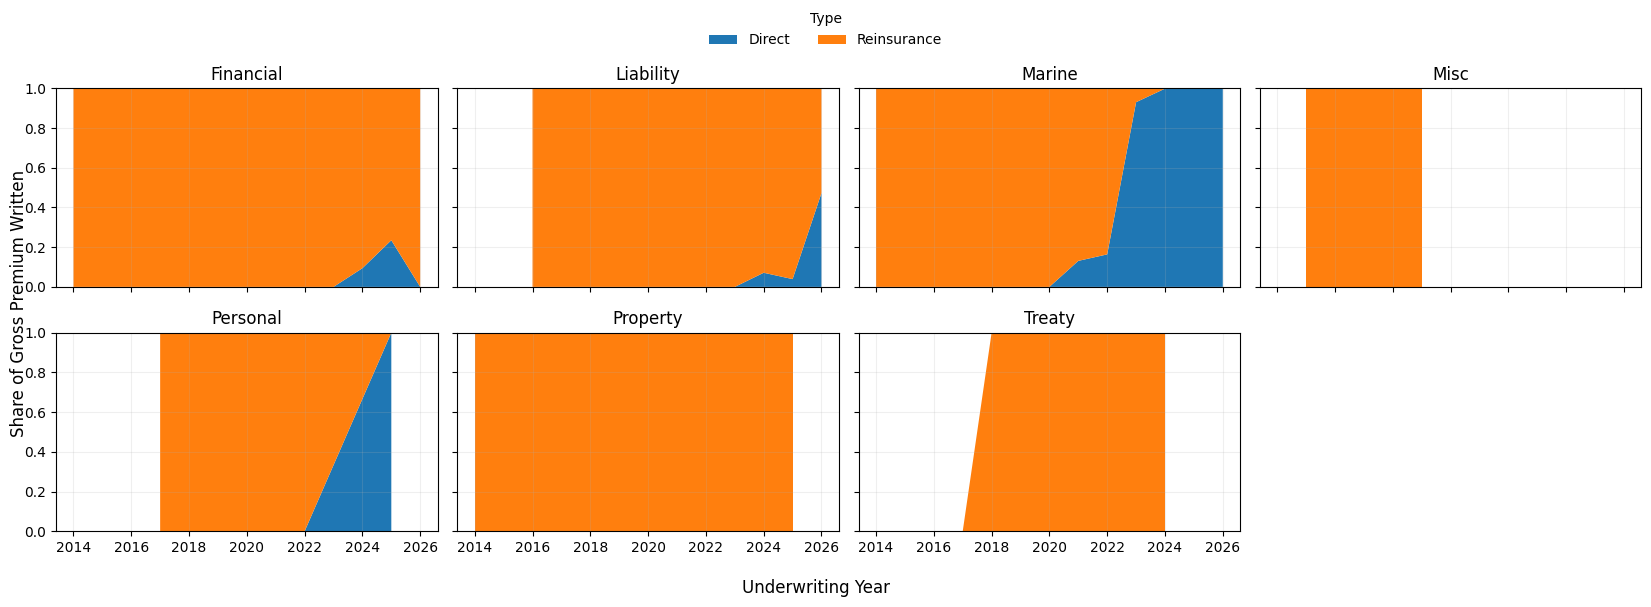

In [47]:
import math
import matplotlib.pyplot as plt

# pivot to LoB x uwy with Type columns for shares
pivot = (
    agg.pivot_table(index=["LoB", "uwy"], columns="Type", values="share", aggfunc="sum")
       .fillna(0)
)

lobs = pivot.index.get_level_values("LoB").unique().tolist()
types = pivot.columns.tolist()

n = len(lobs)
ncols = 4  # set to 3 if you want bigger panels
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4.2, nrows*3.0), sharex=True, sharey=True)
axes = axes.flatten()

for i, lob in enumerate(lobs):
    ax = axes[i]
    p = pivot.loc[lob].sort_index()  # index = uwy

    ax.stackplot(p.index, [p[t].values for t in types], labels=types)
    ax.set_title(lob)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.2)

# remove empty panels
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# one legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Type", loc="upper center", ncol=min(len(types), 5), frameon=False)

fig.supxlabel("Underwriting Year")
fig.supylabel("Share of Gross Premium Written")
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


In [48]:
lob_by_type_gwp = (
    premium_data_df
    .groupby(['uwy', 'LoB', 'Type'], as_index=False)['Gross premium written, USD']
    .sum()
)

lob_by_type_gwp['pct'] = (
    lob_by_type_gwp['Gross premium written, USD']
    / lob_by_type_gwp.groupby(['uwy', 'LoB'])['Gross premium written, USD'].transform('sum')
)


table = (
    lob_by_type_gwp
    .pivot_table(
        index='uwy',
        columns=['LoB', 'Type'],
        values='pct'
    )
    .sort_index(axis=1)
    .sort_index()
)

table.fillna(0)

LoB  Financial             Liability                Marine              \
Type    Direct Reinsurance    Direct Reinsurance    Direct Reinsurance   
uwy                                                                      
2014  0.000000    1.000000  0.000000    0.000000  0.000000    1.000000   
2015  0.000000    1.000000  0.000000    0.000000  0.000000    1.000000   
2016  0.000000    1.000000  0.000000    1.000000  0.000000    1.000000   
2017  0.000000    1.000000  0.000000    1.000000  0.000000    1.000000   
2018  0.000000    1.000000  0.000000    1.000000  0.000000    1.000000   
2019  0.000000    1.000000  0.000000    1.000000  0.000000    1.000000   
2020  0.000000    1.000000  0.000000    1.000000  0.000000    1.000000   
2021  0.000000    1.000000  0.000000    1.000000  0.131038    0.868962   
2022  0.000000    1.000000  0.000000    1.000000  0.163727    0.836273   
2023  0.000000    1.000000  0.000000    1.000000  0.930182    0.069818   
2024  0.094192    0.905808  0.071181    0.928819  0.998516    0.001484   
2025  0.234956    0.765044  0.039223    0.960777  1.000000    0.000000   
2026  0.000000    1.000000  0.472887    0.527113  1.000000    0.000000   

LoB         Misc Personal                Property      Treaty  
Type Reinsurance   Direct Reinsurance Reinsurance Reinsurance  
uwy                                                            
2014         0.0      0.0         0.0         1.0         0.0  
2015         1.0      0.0         0.0         1.0         0.0  
2016         1.0      0.0         0.0         1.0         0.0  
2017         1.0      0.0         1.0         1.0         0.0  
2018         1.0      0.0         1.0         1.0         1.0  
2019         1.0      0.0         1.0         1.0         1.0  
2020         0.0      0.0         1.0         1.0         1.0  
2021         0.0      0.0         1.0         1.0         1.0  
2022         0.0      0.0         1.0         1.0         1.0  
2023         0.0      0.0         0.0         1.0         1.0  
2024         0.0      0.0         0.0         1.0         1.0  
2025         0.0      1.0         0.0         1.0         0.0  
2026         0.0      0.0         0.0         0.0         0.0

In [49]:
lob_by_type_uep = (
    premium_data_df
    .groupby(['uwy', 'LoB', 'Type'], as_index=False)['UEP']
    .sum()
)

lob_by_type_uep['pct'] = (
    lob_by_type_uep['UEP']
    / lob_by_type_uep.groupby(['uwy', 'LoB'])['UEP'].transform('sum')
)


table = (
    lob_by_type_uep
    .pivot_table(
        index='uwy',
        columns=['LoB', 'Type'],
        values='pct'
    )
    .sort_index(axis=1)
    .sort_index()
)

table.fillna(0)

LoB  Financial             Liability             Marine             Personal  \
Type    Direct Reinsurance    Direct Reinsurance Direct Reinsurance   Direct   
uwy                                                                            
2023  0.000000    1.000000  0.000000    0.000000    1.0         0.0      0.0   
2024  0.806863    0.193137  0.000000    1.000000    1.0         0.0      0.0   
2025  0.372052    0.627948  0.000000    1.000000    1.0         0.0      1.0   
2026  0.000000    1.000000  0.484668    0.515332    1.0         0.0      0.0   

LoB     Property  
Type Reinsurance  
uwy               
2023         1.0  
2024         0.0  
2025         1.0  
2026         0.0

In [50]:
# 1) Sum EP by (LoB, UWY, Country)
premium_by_country_long = (
    premium_data_df
    .groupby(['LoB', 'uwy', 'Country'], as_index=False)['Gross premium written, USD']
    .sum()
)

premium_by_country_long['pct_of_lob_uwy'] = (
    premium_by_country_long['Gross premium written, USD']
    / premium_by_country_long
        .groupby(['LoB', 'uwy'])['Gross premium written, USD']
        .transform('sum')
)

premium_by_country_long
#premium_by_country_long.to_csv('exhibits/premium_earned_country_split_uwy_lob_country.csv')


,LoB,uwy,Country,"Gross premium written, USD",pct_of_lob_uwy
0,Financial,2014,Lebanon,-182.609168,0.871189
1,Financial,2014,Syria,-27.000000,0.128811
2,Financial,2015,Hong Kong,25715.960000,0.996450
3,Financial,2015,Russia,131.089852,0.005080
4,Financial,2015,Syria,-33.750000,-0.001308
...,...,...,...,...,...
750,Treaty,2021,Middle East,37076.260000,0.086567
751,Treaty,2021,UAE,318243.703199,0.743043
752,Treaty,2021,Zambia,54227.760000,0.126612
753,Treaty,2022,Middle East,887.270000,0.057176


# Additional calculations for LRC
To get the earning pattern for the LRC payment patterns, we are going to find the weighted time remanining for each LoB and uwy, as a proxy (see LRC calculations in each class)

In [51]:

premium_data_df['lrc_earn_weight'] = np.maximum(premium_data_df['period left'] * premium_data_df['UEP']*premium_data_df['Period'], 0)/365



In [52]:
#LRC earning weights only for non-PAA eligible business

lrc_earning_weight = premium_data_df[premium_data_df['paa_eligible']==False].groupby(['LoB', 'uwy'])[['lrc_earn_weight','UEP']].sum().reset_index()

In [53]:
lrc_earning_weight['lrc_earning_period'] = (lrc_earning_weight['lrc_earn_weight'] / lrc_earning_weight['UEP']).fillna(0)

In [54]:
lrc_earning_weight

,LoB,uwy,lrc_earn_weight,UEP,lrc_earning_period
0,Financial,2015,0.000000e+00,0.000000,0.000000
1,Financial,2016,0.000000e+00,0.000000,0.000000
2,Financial,2017,0.000000e+00,0.000000,0.000000
3,Financial,2018,0.000000e+00,0.000000,0.000000
4,Financial,2020,0.000000e+00,0.000000,0.000000
5,Financial,2021,0.000000e+00,0.000000,0.000000
6,Financial,2022,0.000000e+00,0.000000,0.000000
7,Financial,2023,1.287244e+04,13780.652174,0.934095
8,Financial,2024,1.396976e+06,796187.663901,1.754581
9,Financial,2025,1.769710e+04,31725.222431,0.557824


In [55]:
lrc_earning_weight_long = lrc_earning_weight[['LoB','uwy','lrc_earning_period']]
#lrc_earning_weight_long.drop(columns=['metric'], inplace=True)

In [56]:
premium_data_df

,AM Best classification,"Acquisition, %",Amount due,"Amount due, USD",CCY,Commissioner,Completion,Contract,Country,DAC,...,LoB,currency,uwy,earned_premium,paa_eligible,paa_premium,updated_payment_year,unpaid_premium,period_left_years,lrc_earn_weight
0,"Marine, Aviation & Transport",0.05,7600.0,7600.00,USD,Sun Marine and Trading Management Ltd,2027-01-19 00:00:00,"Bordereau #14, 6955 | 6955",NaN,321.978035,...,Marine,USD,2026,1560.439306,True,6117.582659,2026,NaN,0.802190,5169.291391
1,"Marine, Aviation & Transport",0.05,7600.0,7600.00,USD,Sun Marine and Trading Management Ltd,2027-01-19 00:00:00,"Bordereau #14, 6955 | 6955",NaN,321.978035,...,Marine,USD,2026,1560.439306,True,6117.582659,2026,NaN,0.802190,5169.291391
3,"Marine, Aviation & Transport",0.05,0.0,11756.25,USD,Sun Marine and Trading Management Ltd,2026-01-30 00:00:00,"Bordereau #14, 6862hm | 6862hm",NaN,0.000000,...,Marine,USD,2026,12375.000000,True,0.000000,2026,NaN,0.000000,0.000000
4,"Marine, Aviation & Transport",0.05,0.0,9642.50,USD,Sun Marine and Trading Management Ltd,2026-01-30 00:00:00,"Bordereau #14, 6862pi | 6862pi",NaN,0.000000,...,Marine,USD,2026,10150.000000,True,0.000000,2026,NaN,0.000000,0.000000
6,"Marine, Aviation & Transport",0.05,24225.0,24225.00,USD,Sun Marine and Trading Management Ltd,2027-01-02 00:00:00,"Bordereau #14, 2025-15158-1359 | 2025-15158-1359",NaN,966.758282,...,Marine,USD,2026,6164.834354,True,18368.407364,2026,NaN,0.755647,14620.564225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11162,Commercial Property,0.00,NaN,NaN,USD,NaN,2017-01-31 00:00:00,JAFACPTY-TBA,Vietnam,NaN,...,Property,USD,2016,-1729.270000,True,0.000000,2016,NaN,0.000000,0.000000
11163,Commercial Property,0.00,NaN,NaN,VND,NaN,2018-01-31 23:59:59,JAFACPTY2616,Vietnam,NaN,...,Property,VND,2016,-1303.628416,False,0.000000,2016,NaN,0.000000,0.000000
11164,Commercial Property,0.00,NaN,NaN,USD,NaN,2017-01-31 00:00:00,JAFACPTY-TBA,Vietnam,NaN,...,Property,USD,2016,-1388.560000,True,0.000000,2016,NaN,0.000000,0.000000
11165,Commercial Property,0.00,NaN,NaN,USD,NaN,2017-01-31 00:00:00,JAFACPTY-TBA,Vietnam,NaN,...,Property,USD,2016,-1727.820000,True,0.000000,2016,NaN,0.000000,0.000000


### send data to parquet

In [57]:
lrc_earning_weight_long.to_parquet(exhibits_path + '/lrc_earning_weights.parquet')

In [58]:
premium_data_df['contract_period_years'] = premium_data_df['Period']/365.25

In [59]:
premium_data_for_parquet = premium_data_df.copy()

premium_data_for_parquet = premium_data_for_parquet[['DAC','LoB','uwy','updated_payment_year','Gross premium written, USD','UEP','earned_premium', 'Net premium written, USD','paa_eligible','paa_premium','unpaid_premium','period_left_years','contract_period_years']]

#Note we are only exporting USD values and gross means gross of acquisition costs and net means net of acquisition costs, all values are gross of acqusition cost unless otherwise stated

In [60]:
col_rename = {
    "Gross premium written, USD": "gwp",
    "Net premium written, USD": "gwp_net_dac",
    "UEP": "upr",
    "DAC": "dac",
    "LoB": "lob",
    "earned_premium": "ep",
    "updated_payment_year": "dev_year",  # ← align with earlier usage
}

# optional: normalise column whitespace first (Excel habit)
premium_data_for_parquet = premium_data_for_parquet.copy()
premium_data_for_parquet.columns = premium_data_for_parquet.columns.str.strip()

# rename
premium_data_for_parquet = premium_data_for_parquet.rename(
    columns=col_rename
)

premium_data_for_parquet.head()

premium_data_for_parquet.to_parquet(exhibits_path + '/premium_data.parquet')

In [61]:
# subtract unpaid premium from UEP for PAA eligible contracts 

unpaid_premium = {'Aviation':2641.96,
                  'Marine': 6206504.4,
				  'Liability': 0,
				  'Financial': 844254.64,
				  'Property': 158919.2,
				  'Personal': 0,
				  'Misc': 0,
				  'Treaty': 11737.07}


unpaid_premium_df = pd.DataFrame(list(unpaid_premium.items()), columns=['LoB', 'unpaid_premium_amount'])
unpaid_premium_df['uwy'] = 2025

In [62]:
unpaid_premium_df

,LoB,unpaid_premium_amount,uwy
0,Aviation,2641.96,2025
1,Marine,6206504.40,2025
2,Liability,0.00,2025
3,Financial,844254.64,2025
4,Property,158919.20,2025
5,Personal,0.00,2025
6,Misc,0.00,2025
7,Treaty,11737.07,2025


In [63]:
paa_gross_premium = premium_data_df.groupby(['LoB','uwy'])['paa_premium'].sum().reset_index()
# Merge unpaid_premium into paa_gross_premium for uwy=2025
paa_gross_premium = paa_gross_premium.merge(
    unpaid_premium_df
    .groupby(['LoB', 'uwy'])['unpaid_premium_amount']
    .sum()
    .reset_index(),
    left_on=['LoB', 'uwy'],
    right_on=['LoB', 'uwy'],
    how='left'
)

# Subtract unpaid_premium from paa_premium for uwy=2025
#paa_gross_premium.loc[paa_gross_premium['uwy'] == 2025, 'paa_premium'] -= (
#    paa_gross_premium.loc[paa_gross_premium['uwy'] == 2025, 'unpaid_premium'].fillna(0)
#)

paa_gross_premium['paa_premium_final'] = paa_gross_premium['paa_premium'] - paa_gross_premium['unpaid_premium_amount'].fillna(0)

In [64]:
paa_gross = paa_gross_premium.copy()

## Retro PAA

Manual calculations for now, see manipualted data retro premium